# Part 4 walkthrough — neural exercise boundary (PyTorch)

Run `python run_part4.py` first (about 1.5 min on 2 CPU threads). It trains all four cases and saves the tables and figures this notebook reads. All the modelling code is in `nn_policy.py`.

**Modelling choices that are ours** (everything else follows the assignment):
* The path-bank draw order is **assumed**: $J$, then $S_J\sim A$, then the normals. Confirm it against README.md.
* The in-the-money indicator uses $S_j<K$ on the path. Dates before $J$ get $p_j=0$, so they neither stop nor discount.
* Supervised targets are the stored float64 LS thresholds, cast to float32.

In [1]:
import numpy as np, pandas as pd, torch
pd.set_option("display.width", 160)
import config as cfg, simulation as sim, nn_policy as NP
from IPython.display import Image
print("torch", torch.__version__, "threads", torch.get_num_threads())

torch 2.14.0+cu130 threads 2


## Step 1 — The model maps each date to its own interval network

For $\delta>0$ there are four networks. A dividend date belongs to the interval that **starts** there (post-jump). The cap $U_j$ multiplies the sigmoid, so the boundary can never exceed the Part 1 bound.

In [2]:
for c in (0, 1):
    N, d = sim.CASES[c]; tg = cfg.TimeGrid(N)
    torch.manual_seed(5000 + c); m = NP.BoundaryModel(tg, d)
    print(f"case {c}: {len(m.nets)} net(s); interval of j = 0, d1-1, d1, d3 ->",
          m.interval[[0, tg.div_idx[0]-1, tg.div_idx[0], tg.j_star]].tolist(),
          "| params:", sum(p.numel() for p in m.parameters()))

case 0: 1 net(s); interval of j = 0, d1-1, d1, d3 -> [0, 0, 0, 0] | params: 25
case 1: 4 net(s); interval of j = 0, d1-1, d1, d3 -> [0, 0, 1, 3] | params: 100


## Step 2 — Is the randomised-stopping objective right?

As $\epsilon\to0$ the soft objective must equal the hard-rule payoff. We check this with the LS boundary on a throw-away bank.

In [3]:
display(pd.read_csv("tables/p4_soft_limit_check.csv"))

,case,eps,soft_mean,hard_mean,abs_diff
0,0,1.000000e-07,58.559776,58.559776,7.105427e-15
1,1,1.000000e-07,60.247072,60.247072,7.105427e-15
2,2,1.000000e-07,59.185609,59.185610,9.776378e-07
3,3,1.000000e-07,58.971907,58.971907,7.105427e-15


## Step 3 — Training curves

The supervised loss drops quickly for $\delta=0$ (one smooth curve to match). It stalls higher for $\delta>0$: the LS targets have spikes, and hitting the cap exactly needs sigmoid$\to1$.

The payoff objective is noisy because random start states make batch means vary by about \$1. That noise matters for Step 4.

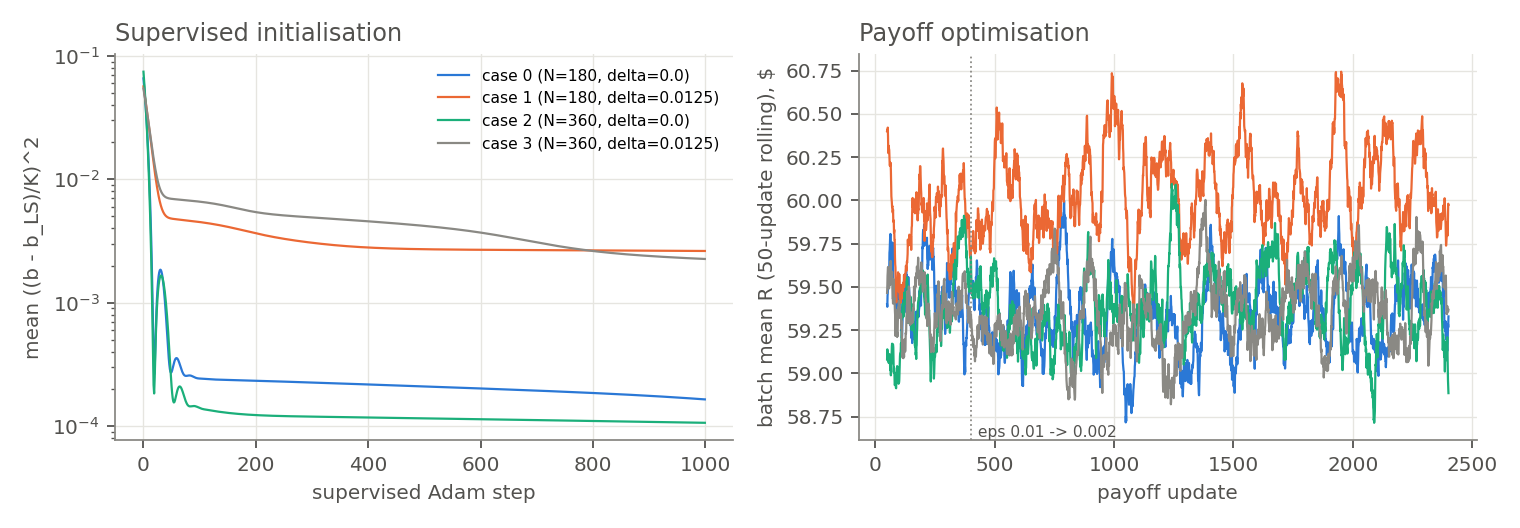

In [4]:
Image("figures/p4_training.png")

## Step 4 — Validation and checkpoint selection

,case,N,delta,val_mean_ckpt0,selected_checkpoint,val_mean_selected,sup_loss_final,time_supervised_s,time_banks_s,time_payoff_s,time_validation_s
0,0,180,0.0000,58.508497,2400,58.530743,0.000164,2.613075,0.156410,13.379667,0.029840
1,1,180,0.0125,58.408609,0,58.408609,0.002625,2.467727,0.131115,17.376052,0.022172
2,2,360,0.0000,59.310853,2400,59.365604,0.000106,1.133255,0.282669,17.399218,0.056426
3,3,360,0.0125,60.548510,0,60.548510,0.002261,2.626416,0.260670,22.062132,0.060967


,case,N,delta,checkpoint,val_mean,diff_vs_ckpt0,se_diff,E_mean_vs_ref,E_max_vs_ref,selected
0,0,180,0.0000,0,58.508497,0.000000,0.000000,0.065330,0.192384,False
1,0,180,0.0000,400,58.529454,0.020956,0.039446,0.019406,0.102897,False
2,0,180,0.0000,800,58.523522,0.015024,0.037337,0.030630,0.094209,False
3,0,180,0.0000,1200,58.473927,-0.034570,0.045810,0.163758,0.240427,False
4,0,180,0.0000,1600,58.526136,0.017638,0.044759,0.027680,0.073511,False
5,0,180,0.0000,2000,58.520896,0.012399,0.041493,0.038519,0.119393,False
6,0,180,0.0000,2400,58.530743,0.022245,0.040807,0.077873,0.229340,True
7,1,180,0.0125,0,58.408609,0.000000,0.000000,0.019469,0.164666,True
8,1,180,0.0125,400,58.360438,-0.048170,0.037353,0.046662,0.213419,False
9,1,180,0.0125,800,58.385612,-0.022997,0.031335,0.043450,0.182892,False


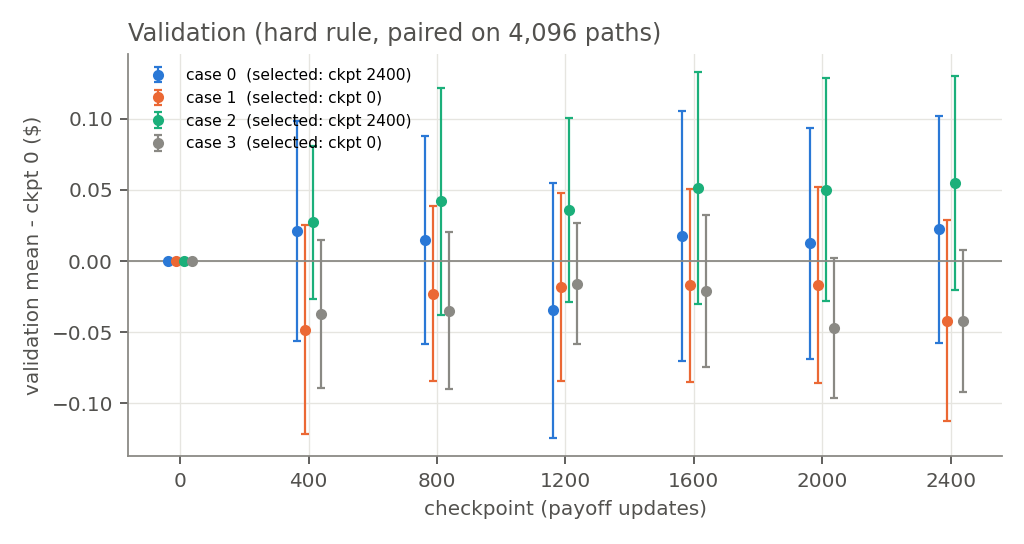

In [5]:
display(pd.read_csv("tables/p4_summary.csv"))
display(pd.read_csv("tables/p4_validation.csv"))
Image("figures/p4_validation.png")

**Reading.**
* All paired gains are within about 2 SE of zero, so selection is close to a coin toss among statistically equal checkpoints.
* Case 2: payoff training improved the boundary a lot ($E_{mean}$ 0.056 → 0.023).
* Case 0: the selected checkpoint has a worse boundary than checkpoint 400. Validation paths rarely start near $t_0$, so the early-date drift goes unpenalised.

## Step 5 — Independent evaluation (float64, 50,000 fresh paths per start)

method             LS         NN  ref-boundary policy
case S0                                              
0    60.0   40.000000  39.130170            40.000000
     80.0   20.652573  20.583641            20.843424
     100.0   8.648361   8.759786             8.773276
1    60.0   40.000000  39.971024            40.000000
     80.0   21.997131  22.009559            22.041170
     100.0  10.028706  10.033442            10.086193
2    60.0   40.000000  40.000000            40.000000
     80.0   20.660366  20.821539            20.849142
     100.0   8.611666   8.688496             8.714538
3    60.0   40.000000  40.000000            40.000000
     80.0   22.069728  22.065153            22.109862
     100.0  10.073332  10.072562            10.094785

,case,pair,S0,mean_diff,se
0,0,LS - NN,60.0,0.869830,0.039323
1,0,LS - ref-boundary policy,60.0,0.000000,0.000000
2,0,NN - ref-boundary policy,60.0,-0.869830,0.039323
3,0,LS - NN,80.0,0.068931,0.029405
4,0,LS - ref-boundary policy,80.0,-0.190852,0.034324
5,0,NN - ref-boundary policy,80.0,-0.259783,0.035463
6,0,LS - NN,100.0,-0.111425,0.020113
7,0,LS - ref-boundary policy,100.0,-0.124915,0.022751
8,0,NN - ref-boundary policy,100.0,-0.013490,0.014170
9,1,LS - NN,60.0,0.028976,0.009663


,case,N,delta,method,E_mean,E_max,j_at_max
0,0,180,0.0000,LS,0.065132,0.164848,179
1,0,180,0.0000,NN,0.077873,0.229340,0
2,1,180,0.0125,LS,0.032329,0.234600,152
3,1,180,0.0125,NN,0.019469,0.164666,170
4,2,360,0.0000,LS,0.055484,0.199469,357
5,2,360,0.0000,NN,0.023441,0.166370,359
6,3,360,0.0125,LS,0.046729,0.387941,288
7,3,360,0.0125,NN,0.042856,0.229499,300


,N,method,A,B,F
0,180,ref,0.0,0.000000,0.000000
1,180,LS,0.0,0.000000,0.200384
2,180,NN,32.0,0.133758,0.150714
3,180,ref: max (V0 - V0.0125)^+ $,NaN,NaN,0.000000
4,360,ref,0.0,0.000000,0.000000
5,360,LS,0.0,0.000000,0.102824
6,360,NN,0.0,0.000000,0.056080
7,360,ref: max (V0 - V0.0125)^+ $,NaN,NaN,0.000000


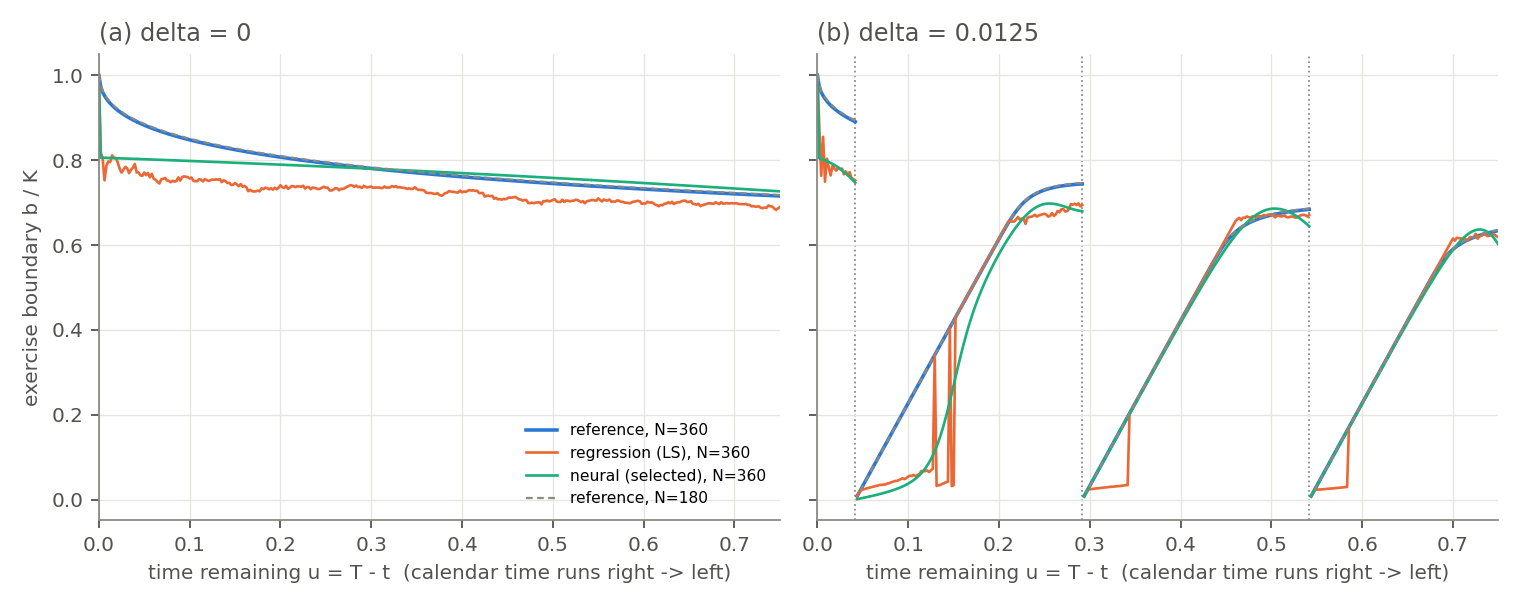

In [6]:
p = pd.read_csv("tables/p5_prices.csv")
display(p.pivot_table(index=["case","S0"], columns="method", values="mean"))
display(pd.read_csv("tables/p5_paired.csv"))
display(pd.read_csv("tables/p5_boundary_errors.csv"))
display(pd.read_csv("tables/p1_ordering_checks.csv"))
Image("figures/fig1_boundaries.png")